# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [2]:
from src.utils.sam_utils import download_model_weight, download_model_config

INSTALL = False
if INSTALL:
    download_model_weight("sam2.1_hiera_large.pt")
    download_model_config("sam2.1_hiera_l.yaml")
    !pip install sam2


In [3]:
import os
import pandas as pd
from src.core.FixationTask import FixationTask
from src.core.Participant import Participant
from src.core.ImageData import ImageData
from src.core.Mask import Mask
from src.models.MaskGenerator import SAM2

from src.prompts.gaze_prompts import *

In [4]:
font_color =  "yellow"          
COLOR_CODE_1 = "fixation_scarletred_meddark"
COLOR_CODE_2 = "aluminium"
COLOR_CODE_3 = "yellow"

In [5]:

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

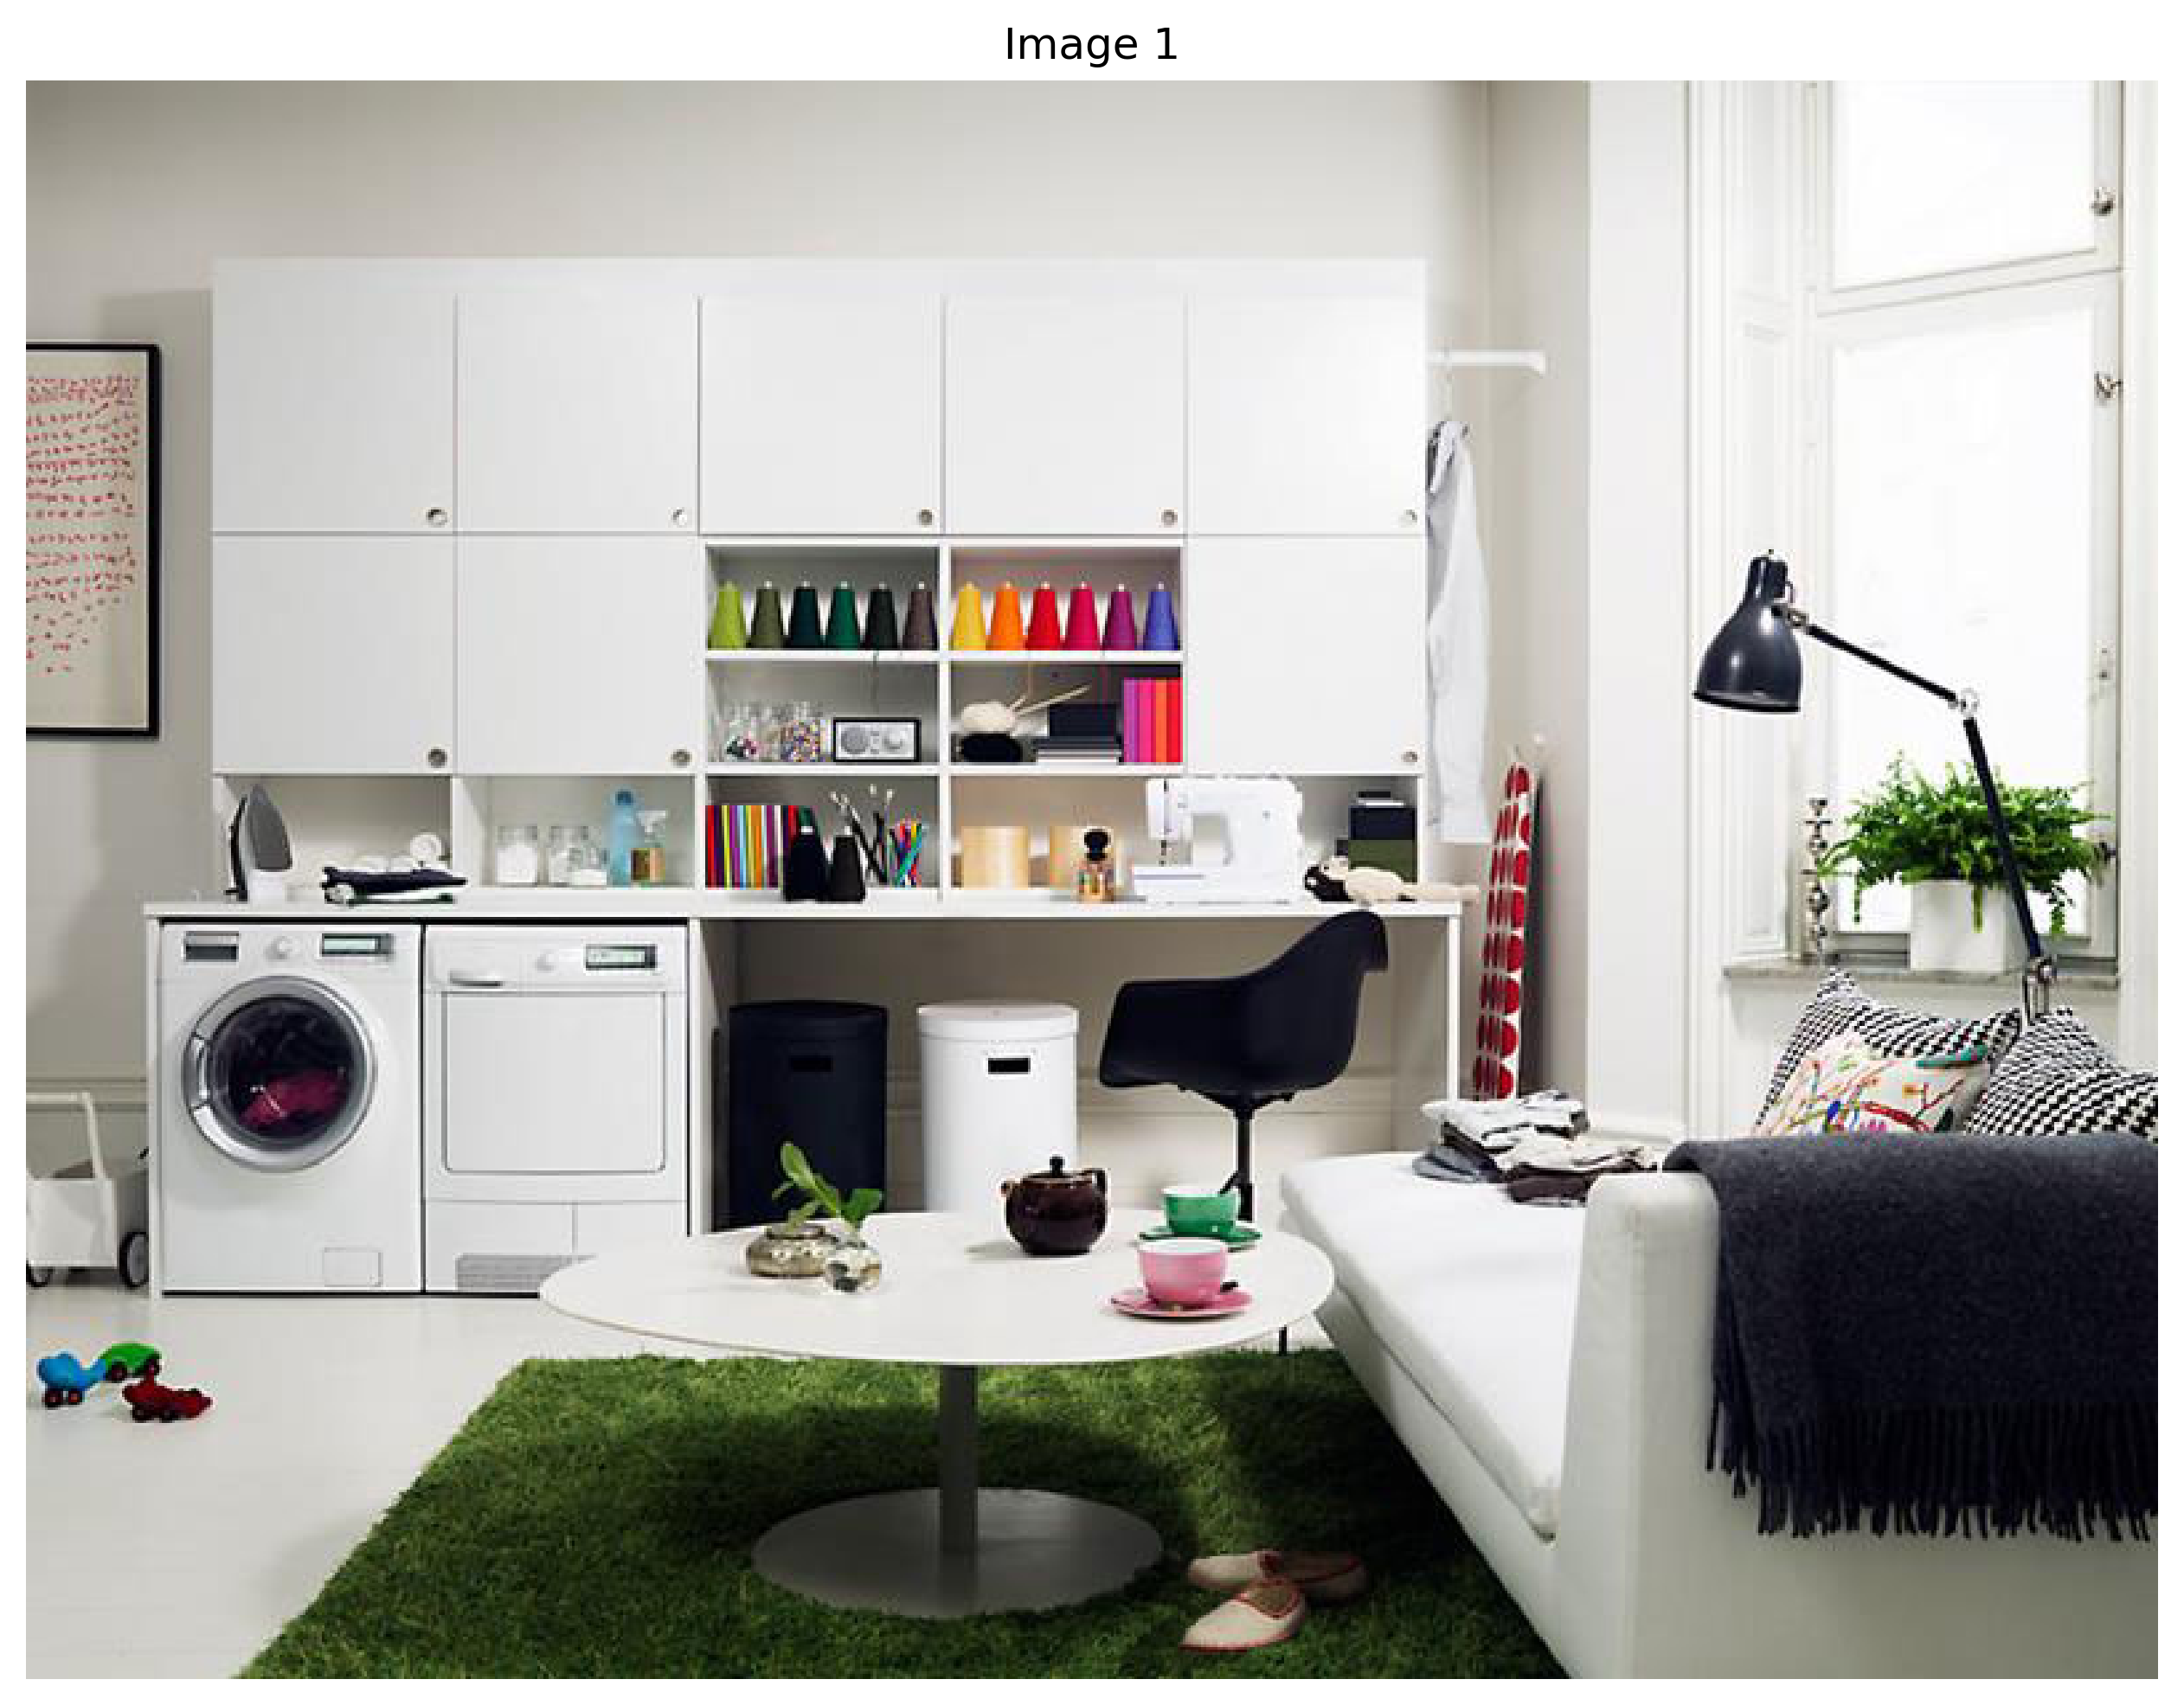

In [6]:
IMG_ID = 1
imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
imageData = ImageData(imgpath)
imageData.show()

## Testing Gaze Points


In [7]:
datapath =  os.path.join("data", "experiments", "XSQ_Expt1_Data_2.csv")
data = pd.read_csv(datapath)

In [8]:
IMG_ID = 1
part_ID = int(data[data.ItemNum == IMG_ID].ParticipantID.unique()[0])
participant =  Participant(part_ID)
print("Participant ID:", part_ID)

imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
print("Image Path:", imgpath)

imageData = ImageData(imgpath, target = [430, 510, 545, 595], img_type = "exp")

CONDITION_ID = 1
GROUP_ID = 1
task = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=3)

Participant ID: 2
Image Path: .\data\images\1exp.jpg
Participant data before center bias removal:  4
Participant data after center bias removal:  1


In [9]:
task_data = task.data.copy()

In [ ]:
prompt_0 = task_data.iloc[0]
prompt_1 = task_data.iloc[1]
prompt_2 = task_data.iloc[2]

### Point Gaze Prompt

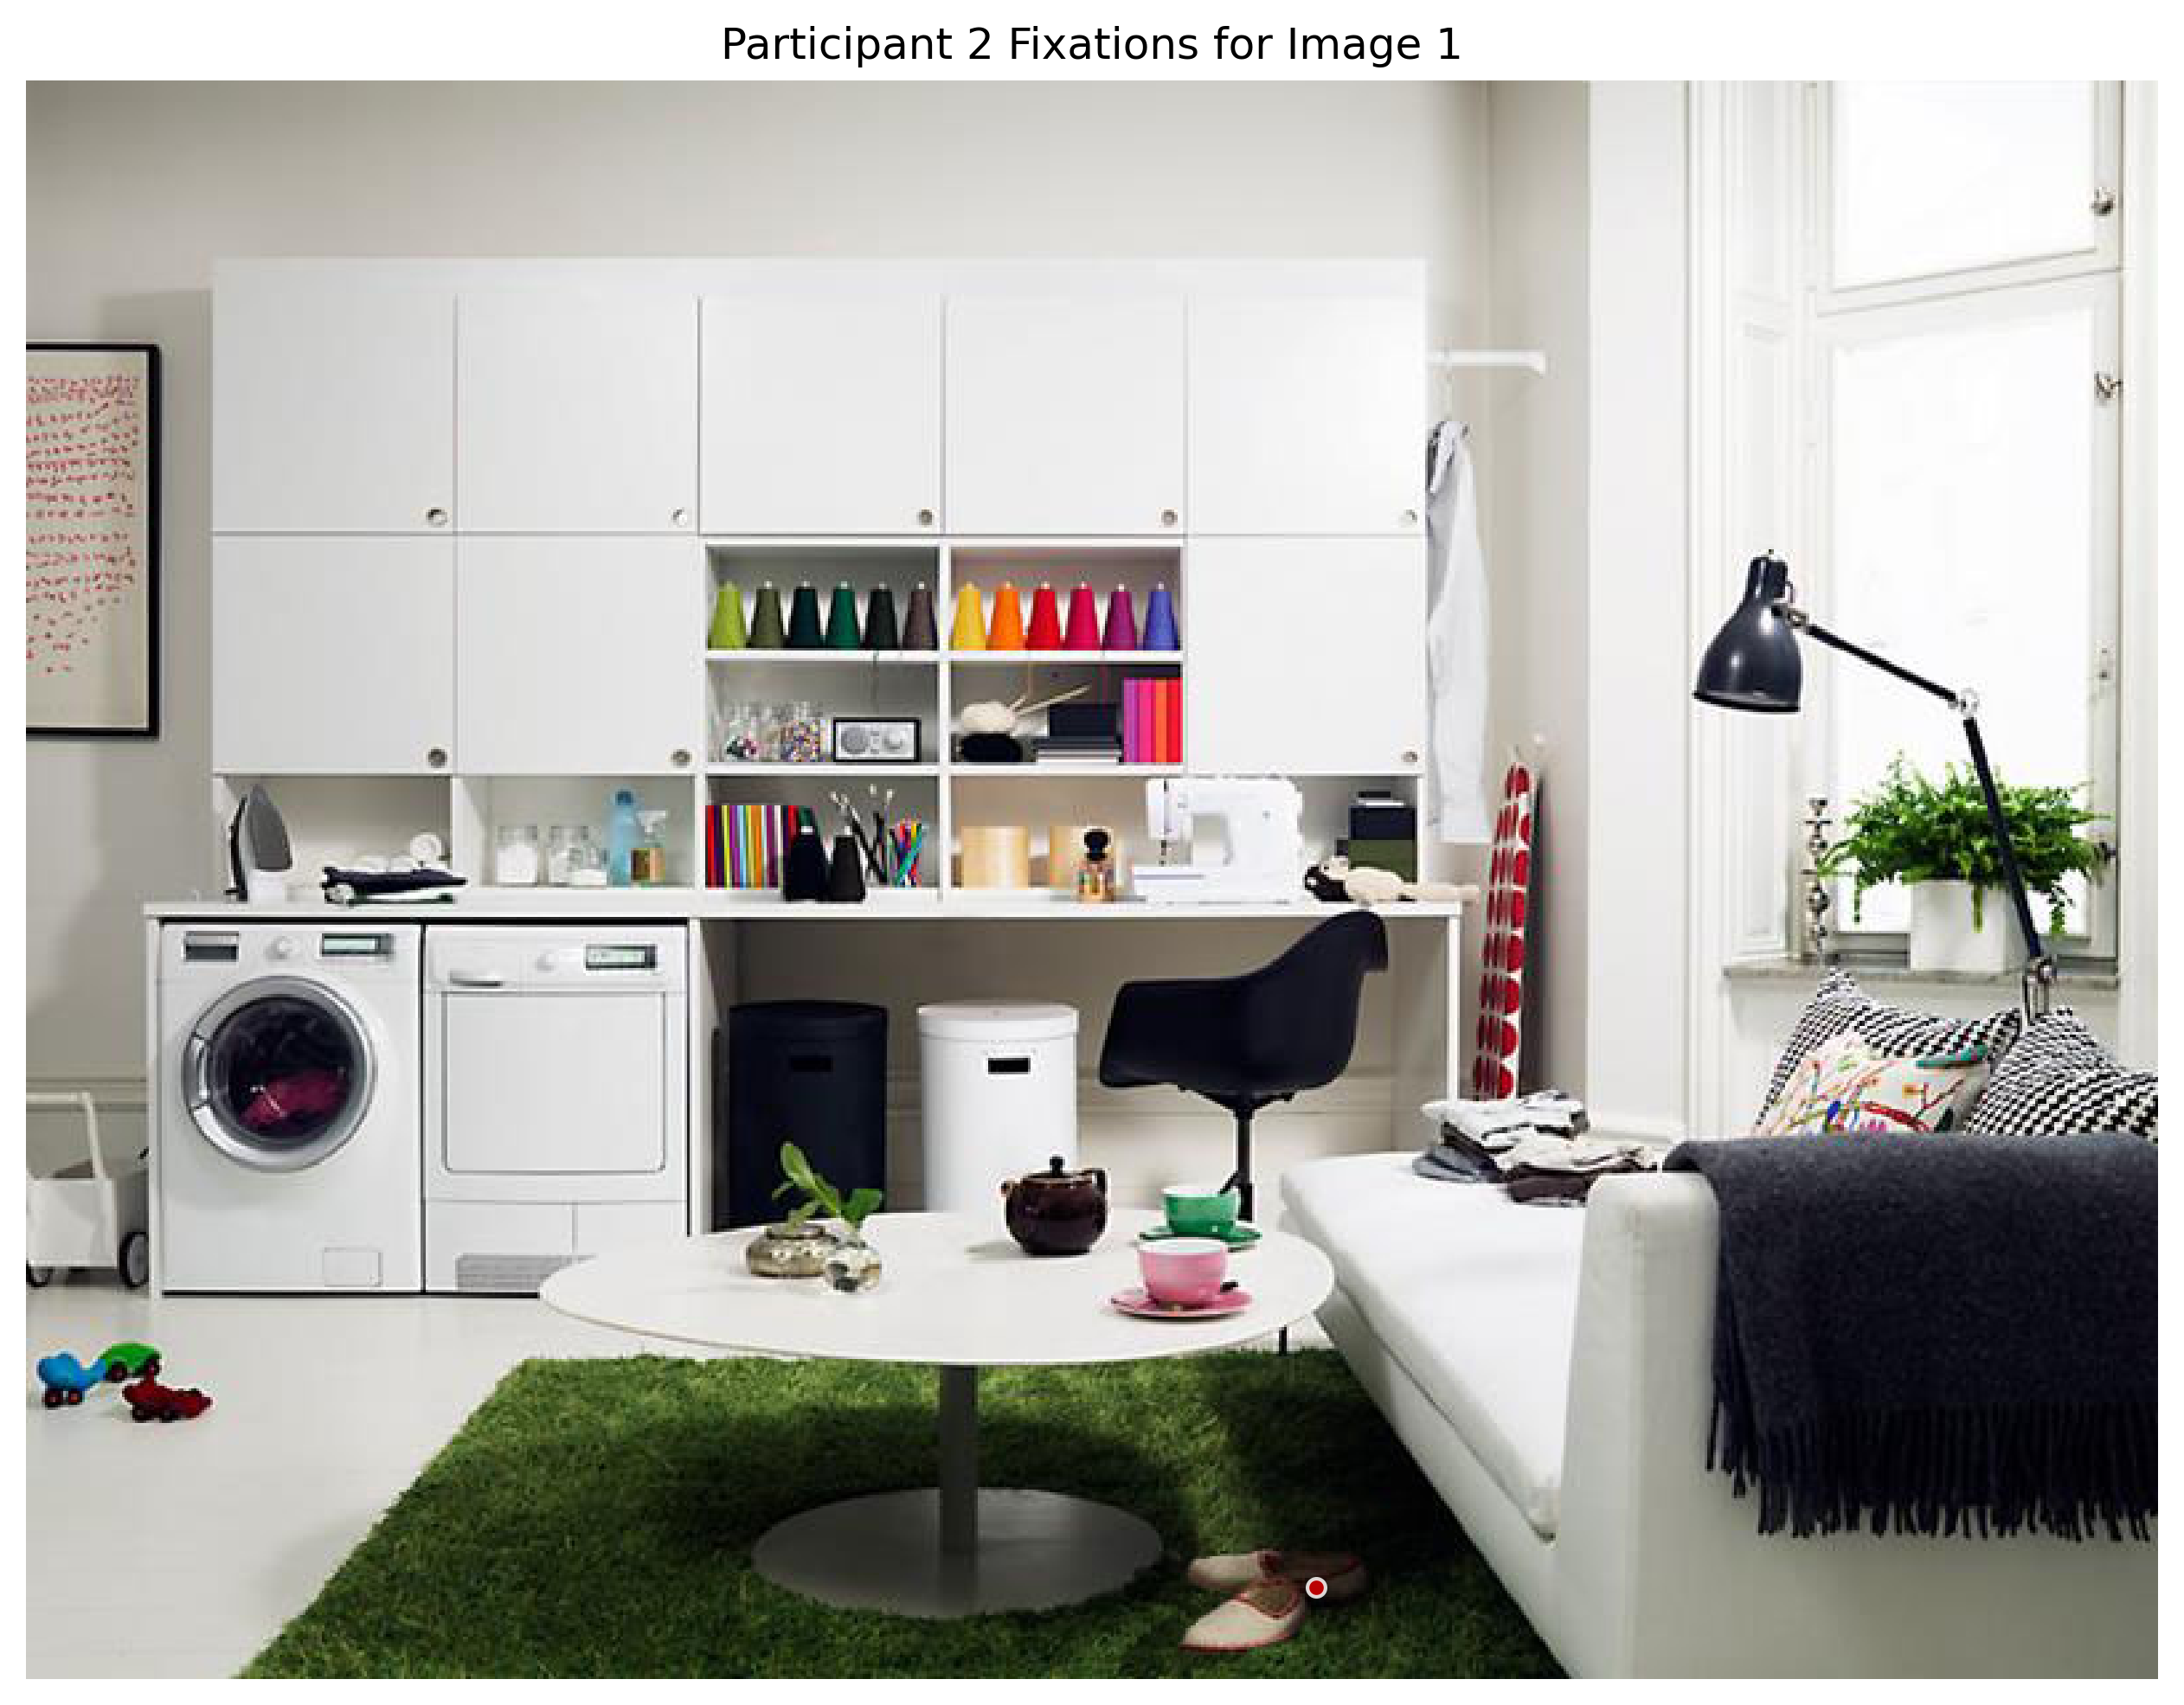

In [11]:
aug_task_data = sample_points_point(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Triangle Gaze Prompt

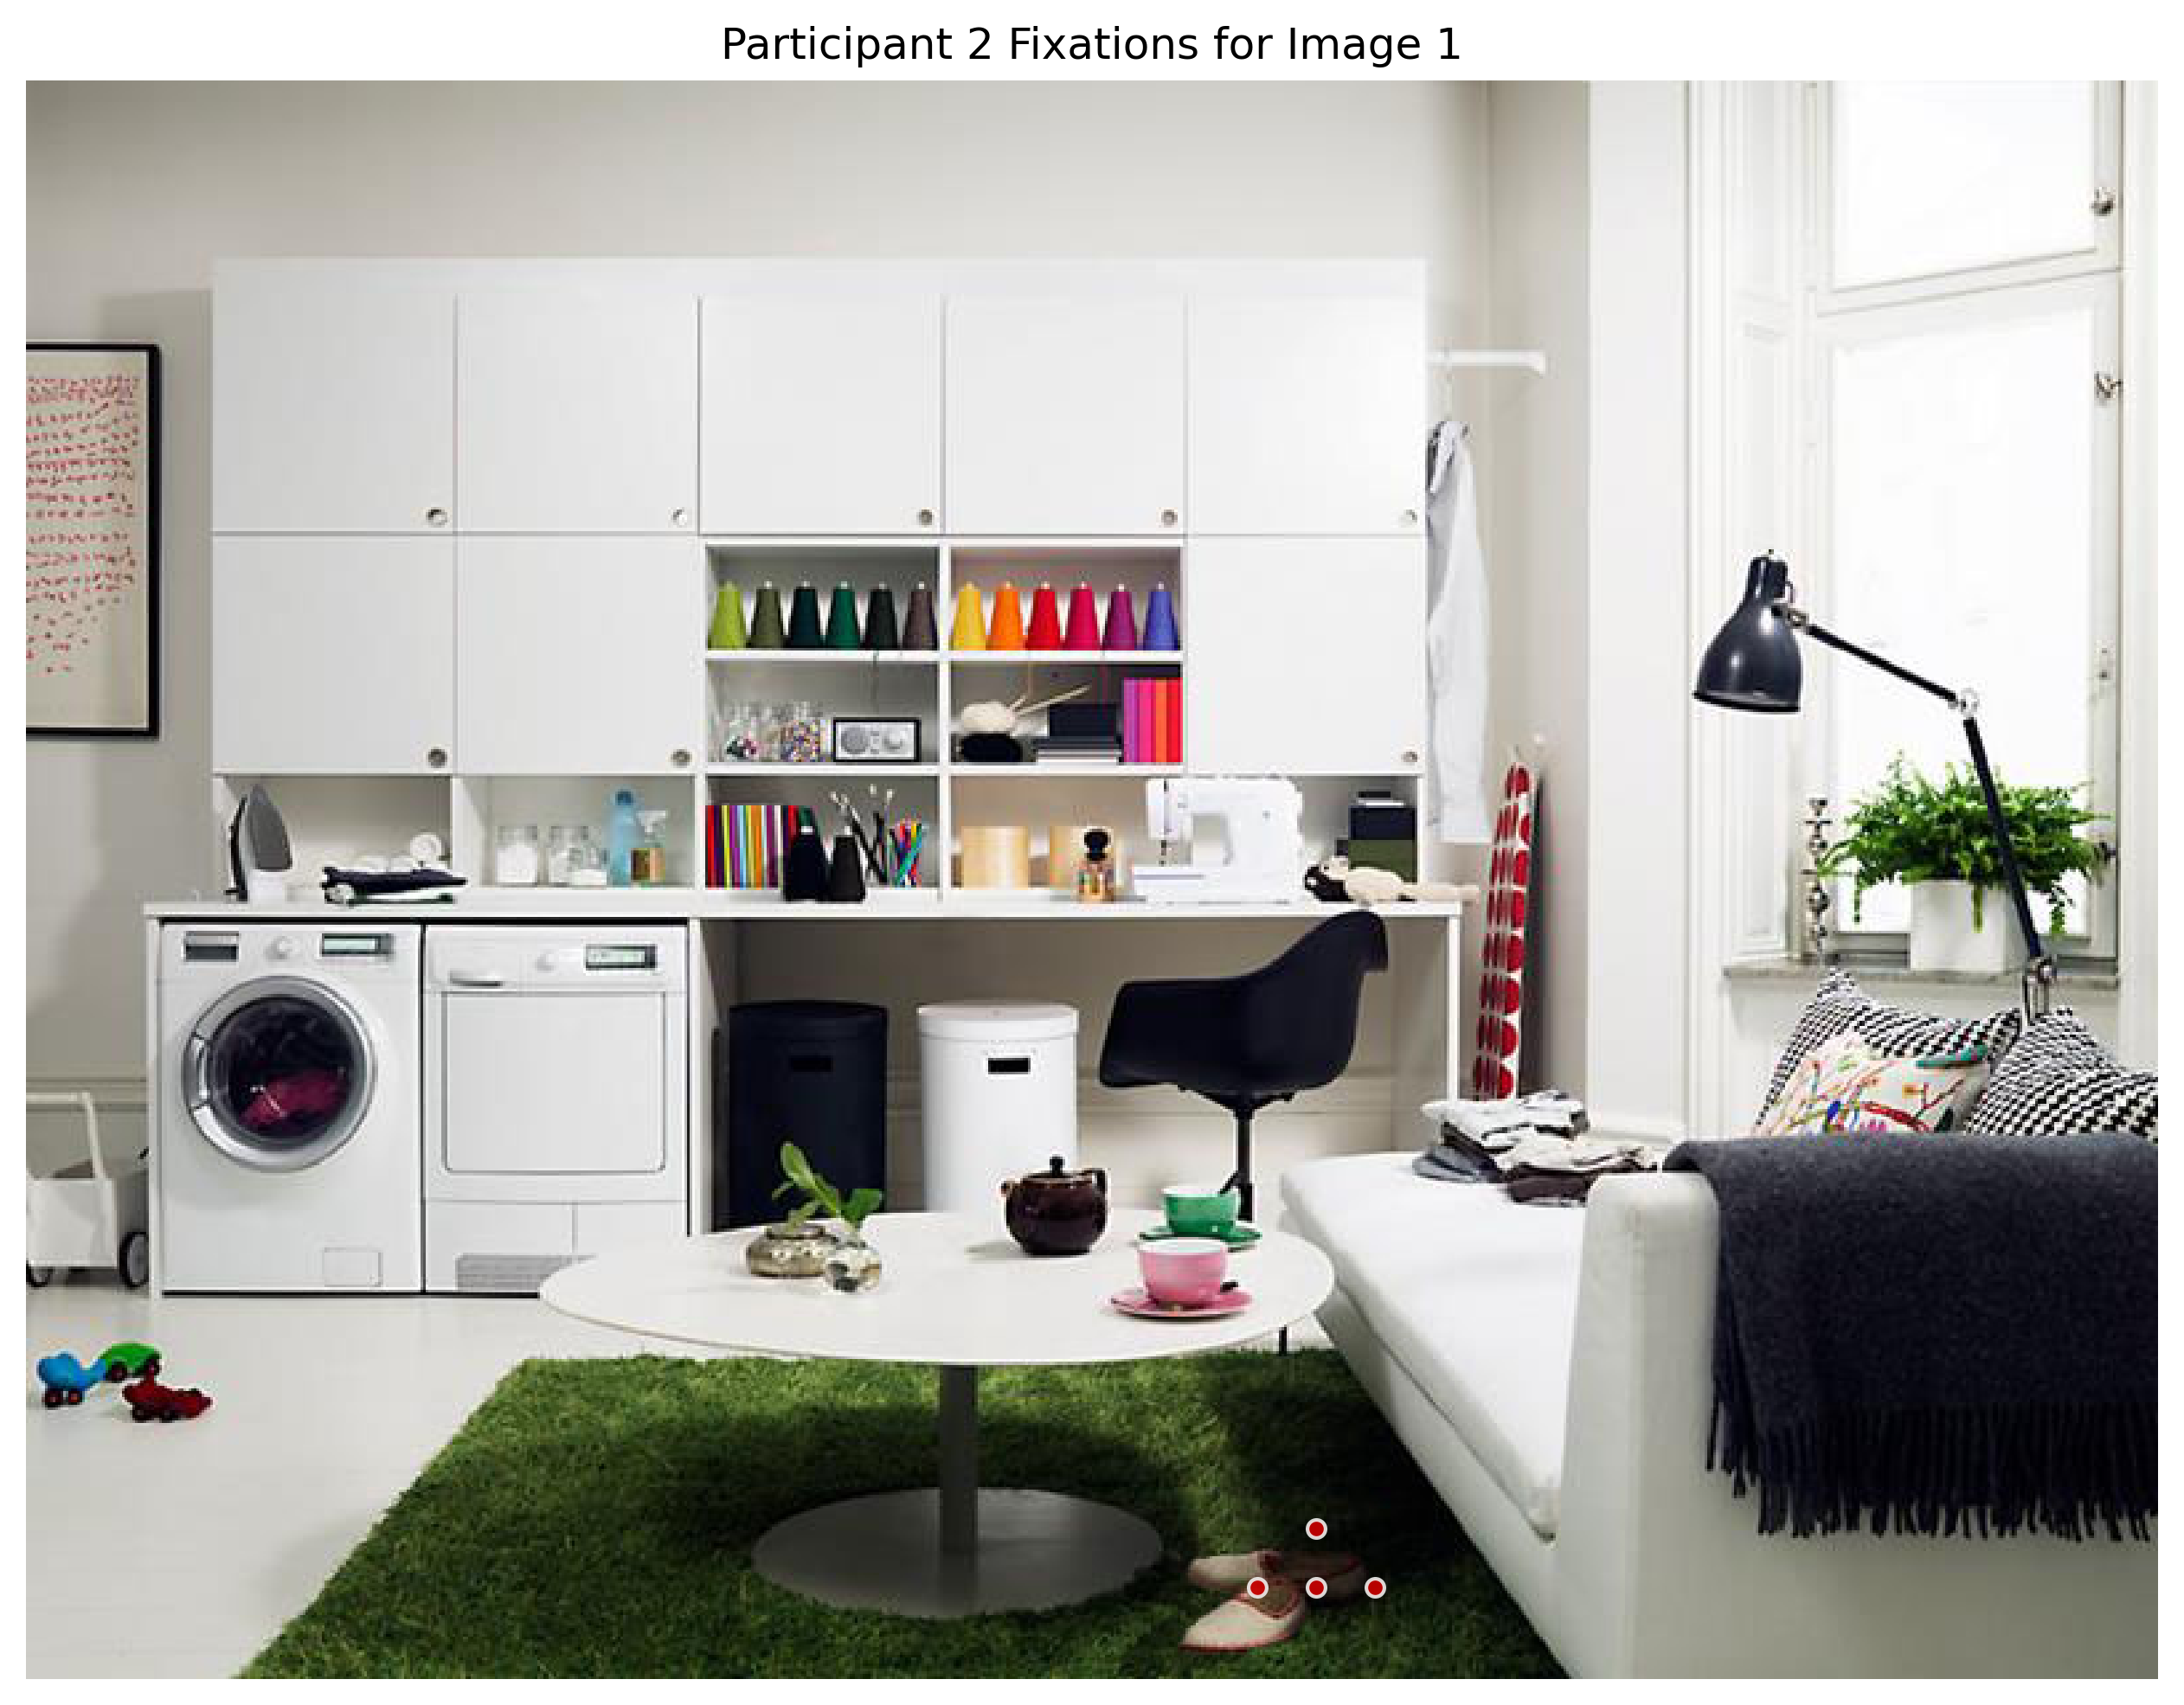

In [12]:
aug_task_data = sample_points_triangle(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Cross Gaze Prompt

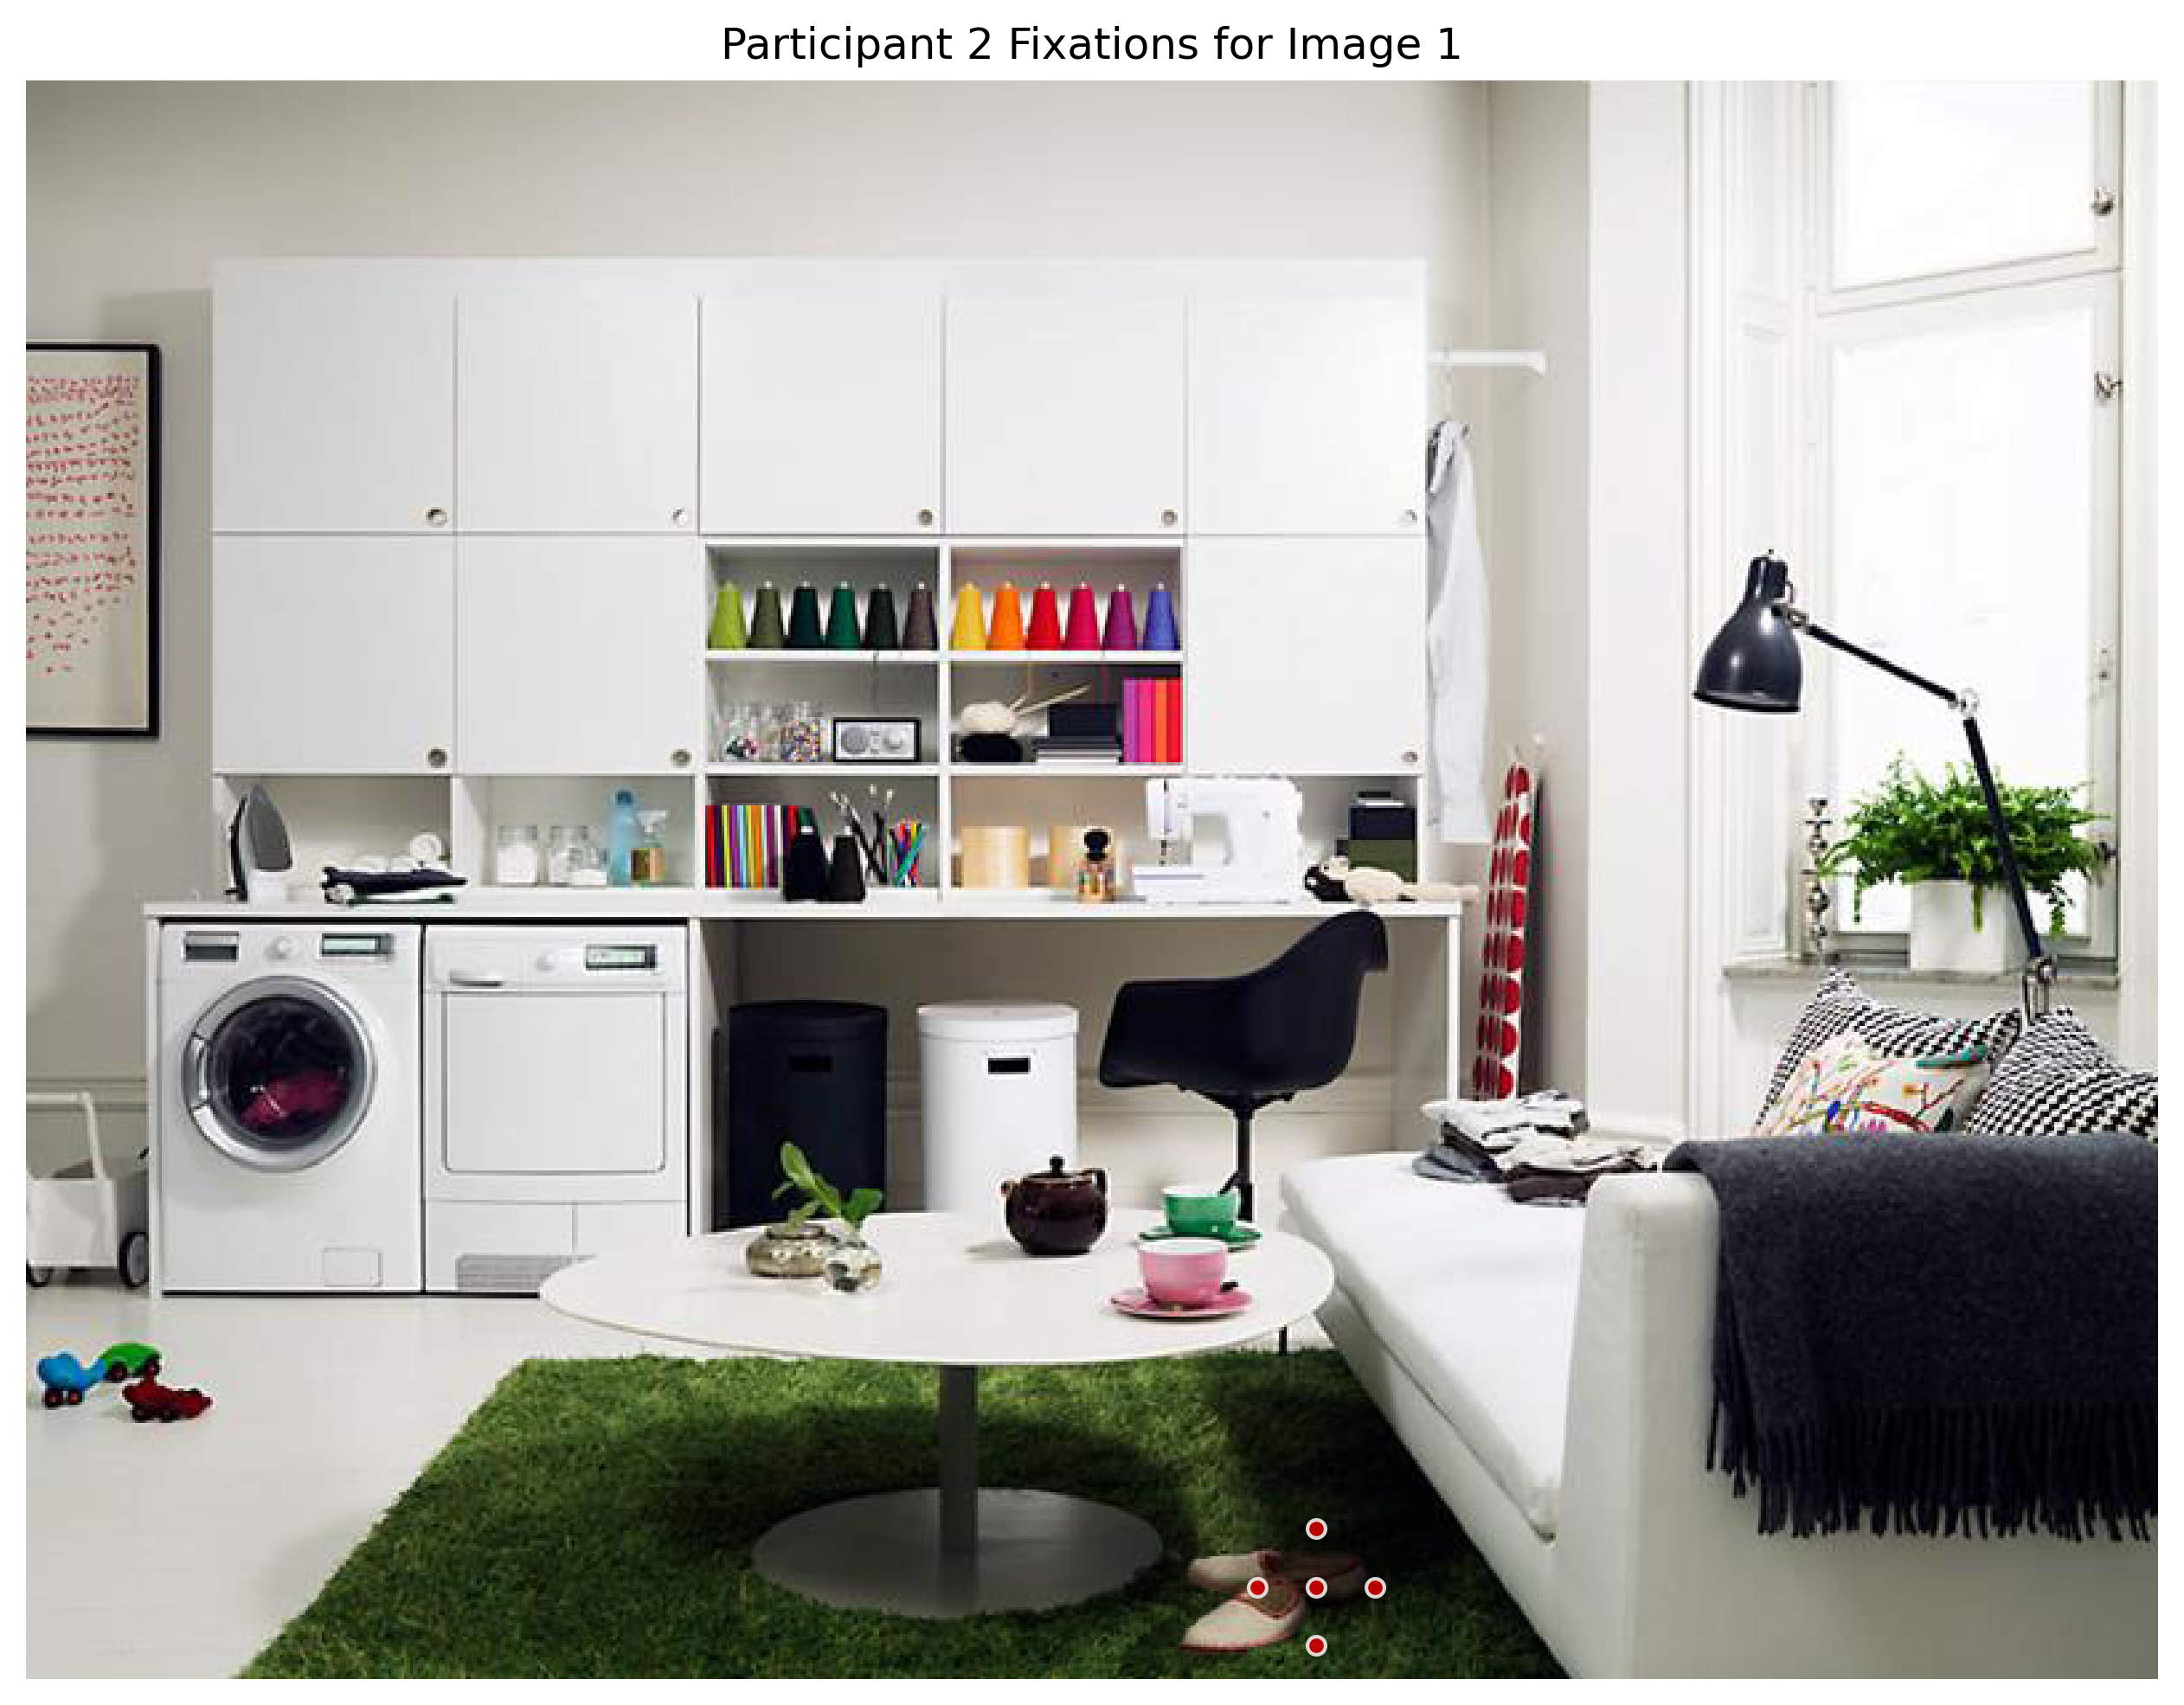

In [13]:
aug_task_data = sample_points_cross(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Circle Gaze Prompt

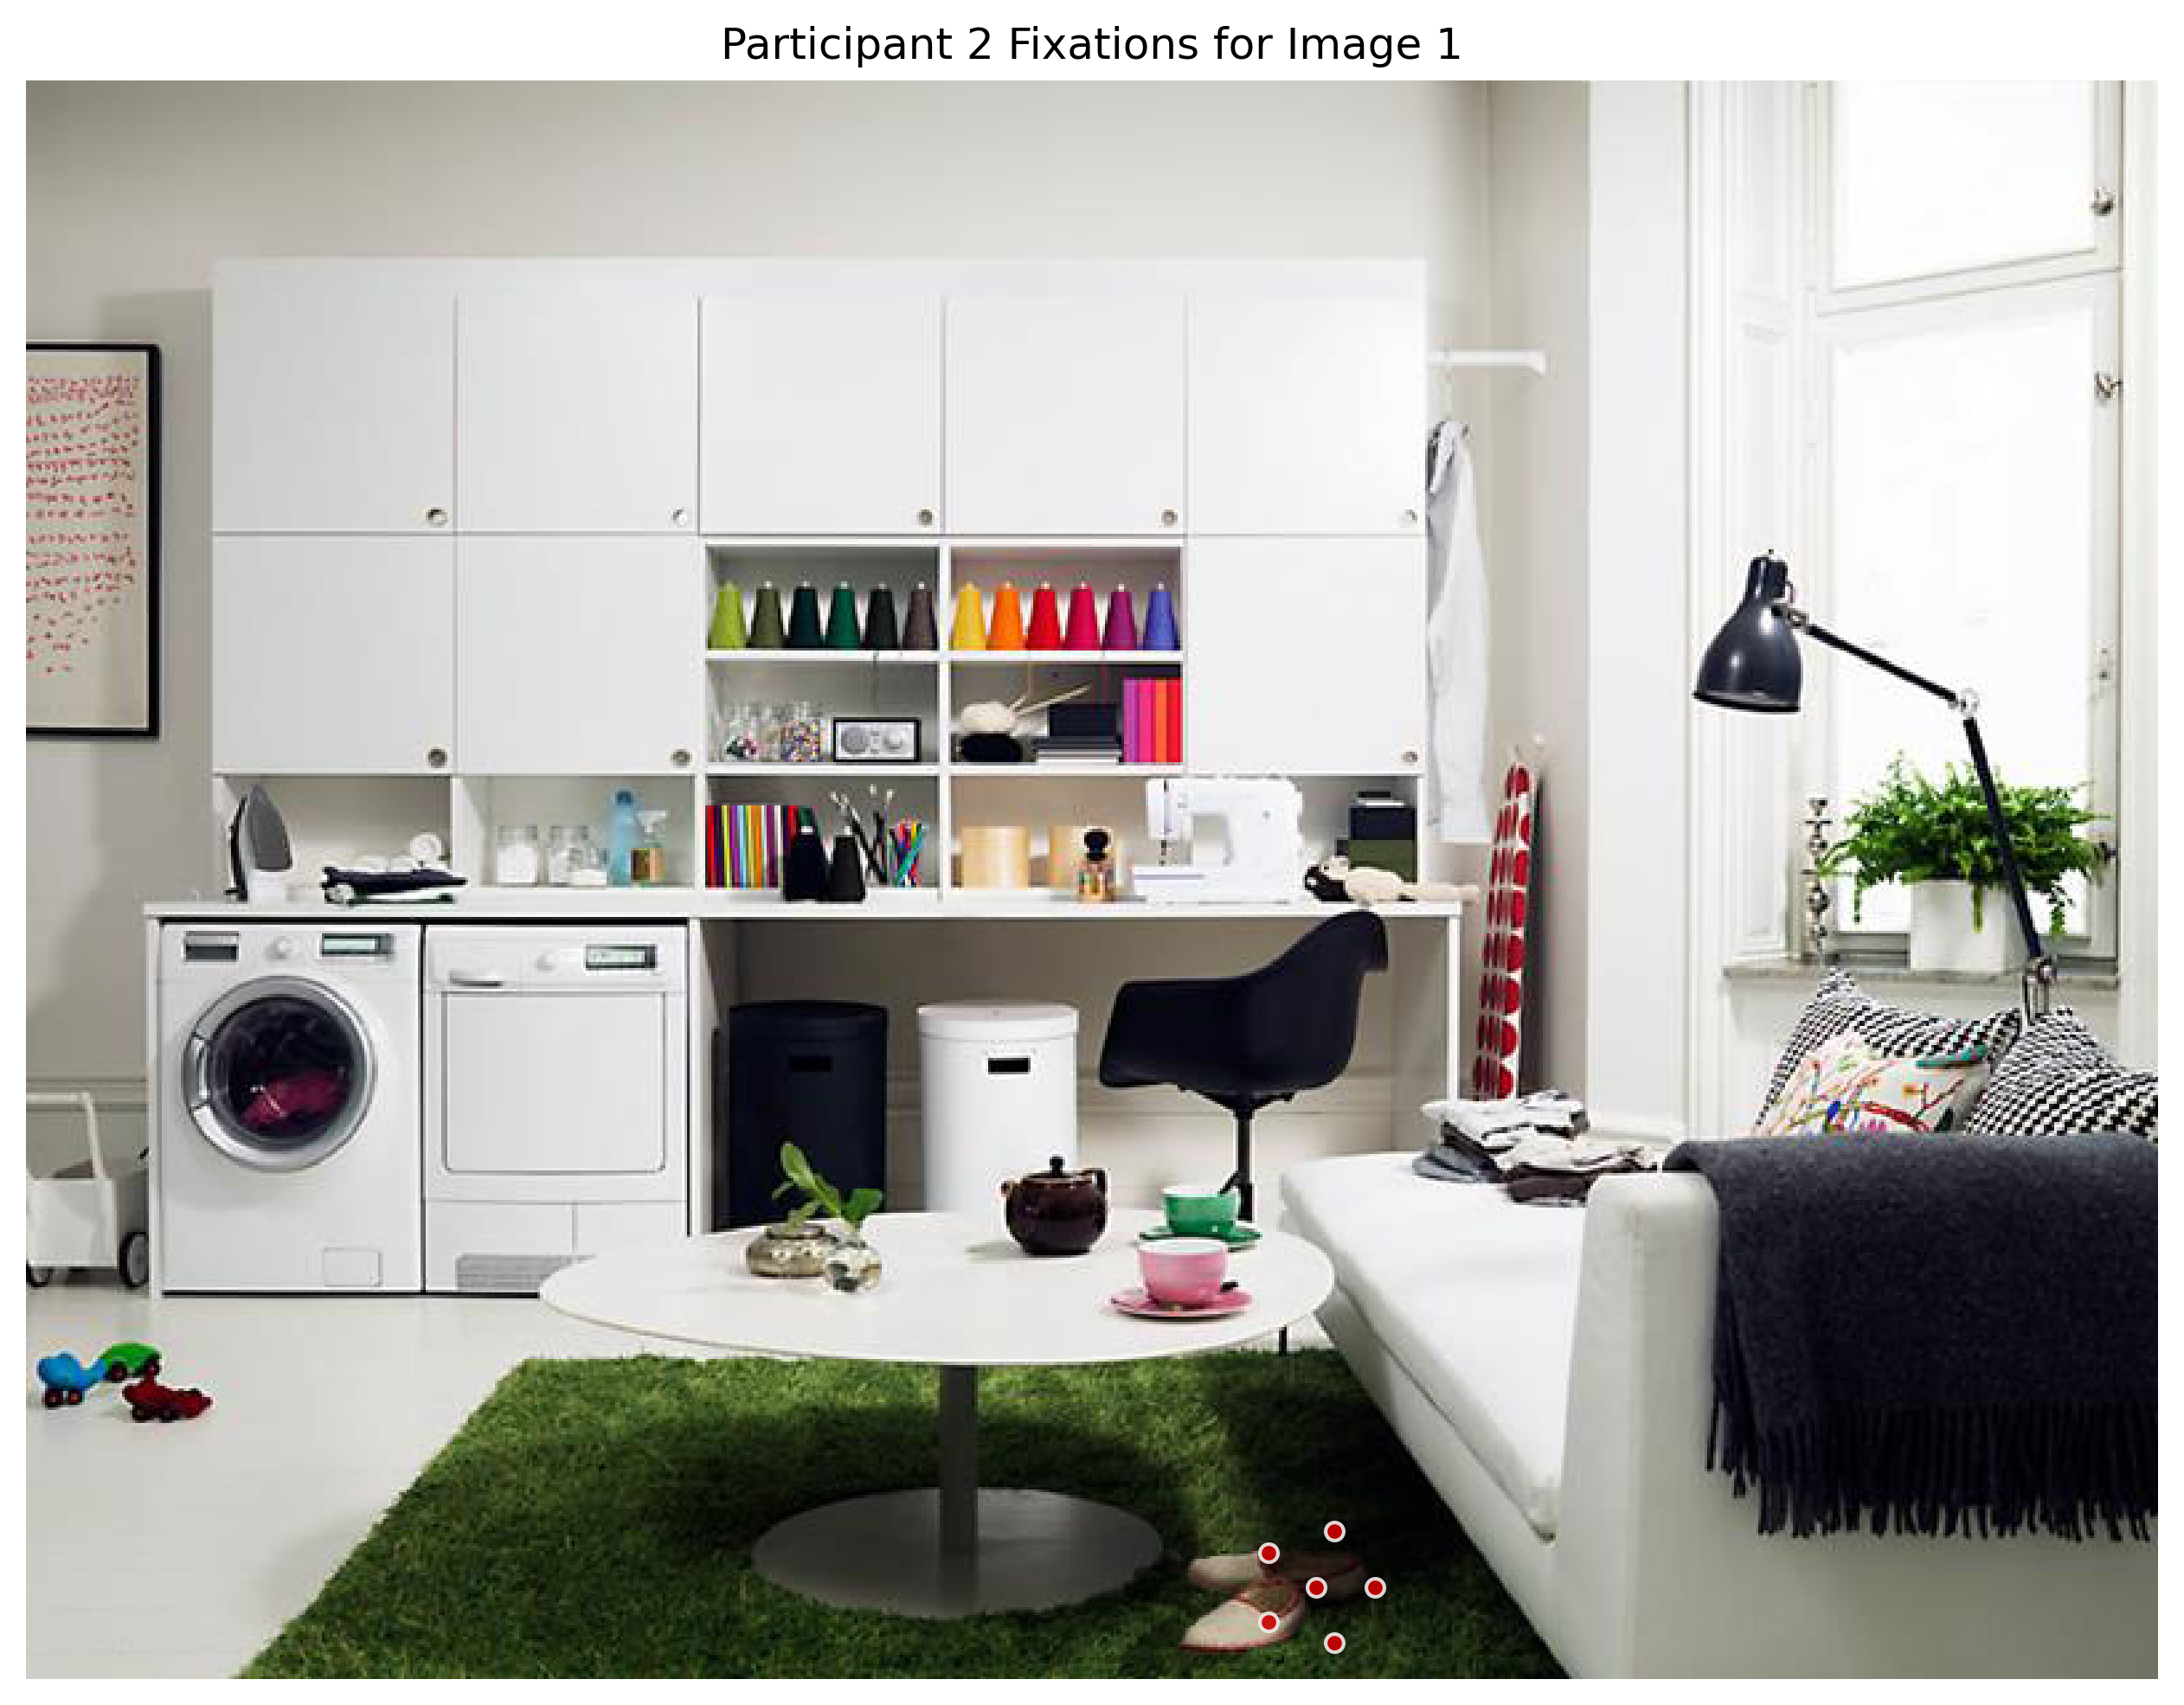

In [14]:
aug_task_data = sample_points_circle(prompt_0, N = 5)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

## Testing Mask Segmentation and Labeling

Generate the description for this scene

In [15]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance

In [16]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

Image Path: .\data\images\1exp.jpg
Processing image ID: 1
	Generating general scene description...
Scene description completed in 26.01 seconds
[  2   3   5   6   8   9  11  12  14  15  16  17  18  20  21  22  23  24
  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  44  45  46  47  48  49  50  52  53  54  55  56  58  59  60  61  62  63
  64  66  67  69  70  71  73  74  75  76  77  78  82  83  84  86  87  88
  89  90  93  94  95  96  97  98  99 100 101 102 103 104 105]

Processing participant ID = 2

Participant data before center bias removal:  4
Participant data after center bias removal:  1
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8931


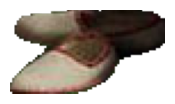

Mask labeling completed in 0.93 seconds
Mask labeling completed in 1.36 seconds
Mask labeling completed in 0.64 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.93 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 0.70 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 3

Participant data before center bias removal:  4
Participant data after center bias removal:  1
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8244


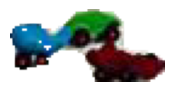

Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.61 seconds
Mask labeling completed in 0.52 seconds
Mask labeling completed in 0.68 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 1.27 seconds
Mask labeling completed in 1.01 seconds
Mask labeling completed in 0.62 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']

Processing participant ID = 5

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 6

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 8

Participant data before center bias removal:  2
Participant data after center bias removal:  0
cuda

Processing participant ID = 9

Participant data before center bias removal:  2
Participant data after center bias removal:

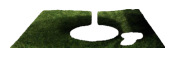

Mask labeling completed in 0.80 seconds
Mask labeling completed in 1.30 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 1.19 seconds
Mask labeling completed in 0.62 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.85 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9762


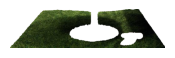

Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 1.83 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 1.21 seconds
Mask labeling completed in 1.04 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.70 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8818


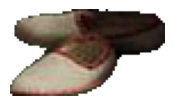

Mask labeling completed in 0.95 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.55 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.87 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 16

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 17

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 18

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 20

Participant data before center bias removal:  5

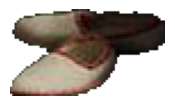

Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.98 seconds
Mask labeling completed in 2.43 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 1.15 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 1.49 seconds
Mask labeling completed in 0.84 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8915


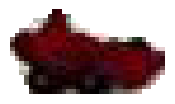

Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 1.20 seconds
Mask labeling completed in 1.03 seconds
Mask labeling completed in 0.90 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.74 seconds
['toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy']

Processing participant ID = 21

Participant data before center bias removal:  8
Participant data after center bias removal:  5
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: triangle, score: 0.8527


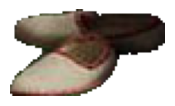

Mask labeling completed in 0.58 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.60 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.74 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8299


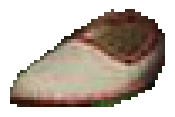

Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.65 seconds
Mask labeling completed in 1.13 seconds
Mask labeling completed in 0.80 seconds
['slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8905


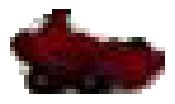

Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.97 seconds
Mask labeling completed in 1.10 seconds
Mask labeling completed in 0.64 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.51 seconds
['toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy', 'toy']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: circle, score: 0.5291


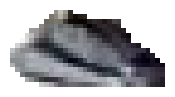

Mask labeling completed in 0.96 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.90 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.82 seconds
['cushion', 'cushion', 'cushions', 'cushion', 'cushion', 'cushions', 'cushion', 'cushions', 'cushion', 'cushion']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.7602


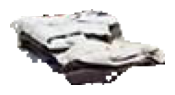

Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 1.15 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 0.81 seconds
['clothes', 'clothes', 'clothes', 'clothes', 'clothes', 'laundry', 'clothes', 'clothes', 'clothes', 'clothes']

Processing participant ID = 22

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 23

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 24

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 26

Participant data before center bias removal:  3
Participa

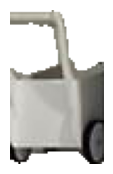

Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.65 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.58 seconds
Mask labeling completed in 0.57 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.49 seconds
['cart', 'cart', 'cart', 'cart', 'cart', 'cart', 'cart', 'cart', 'cart', 'cart']

Processing participant ID = 28

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 29

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 30

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 31

Participant data before center bias removal:  3
Participant data after center bias remo

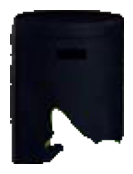

Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.95 seconds
Mask labeling completed in 4.28 seconds
Mask labeling completed in 1.03 seconds
Mask labeling completed in 0.65 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.76 seconds
['hamper', 'hamper', 'hamper', 'hamper', 'lamp', 'hamper', 'hamper', 'lamp', 'bin', 'lamp']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8098


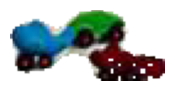

Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 1.00 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 0.48 seconds
Mask labeling completed in 0.89 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.7738


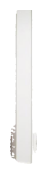

Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.57 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.63 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.57 seconds
['lamp', 'lamp', 'lamp', 'lamp', 'lamp', 'lamp', 'lamp', 'lamp', 'lamp', 'lamp']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: circle, score: 0.7618


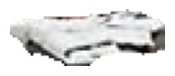

Mask labeling completed in 0.54 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.68 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.50 seconds
Mask labeling completed in 0.56 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.74 seconds
['ironing', 'laundry', 'laundry', 'ironing', 'laundry', 'ironing', 'ironing', 'ironing', 'ironing', 'ironing']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.7808


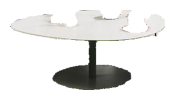

Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.63 seconds
['table', 'table', 'table', 'table', 'table', 'table', 'table', 'table', 'table', 'table']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9474


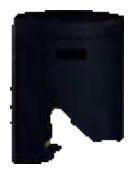

Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.65 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.68 seconds
Mask labeling completed in 0.74 seconds
['lamp', 'lamp', 'hamper', 'hamper', 'hamper', 'hamper', 'lamp', 'hamper', 'hamper', 'hamper']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9622


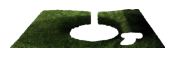

Mask labeling completed in 1.01 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.90 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.53 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.62 seconds
Mask labeling completed in 1.03 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']

Processing participant ID = 33

Participant data before center bias removal:  3
Participant data after center bias removal:  0
cuda

Processing participant ID = 34

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 35

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 36

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cu

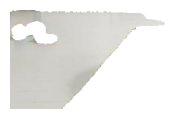

Mask labeling completed in 1.06 seconds
Mask labeling completed in 1.38 seconds
Mask labeling completed in 1.27 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 1.16 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.53 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.97 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8501


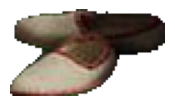

Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 1.19 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 1.26 seconds
Mask labeling completed in 1.19 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 39

Participant data before center bias removal:  3
Participant data after center bias removal:  0
cuda

Processing participant ID = 40

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 41

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 42

Participant data before center bias removal:  0

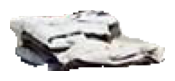

Mask labeling completed in 0.95 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.68 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 1.02 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 1.31 seconds
Mask labeling completed in 2.05 seconds
Mask labeling completed in 1.40 seconds
['laundry', 'clothes', 'clothes', 'clothes', 'laundry', 'clothes', 'clothes', 'clothes', 'clothes', 'clothes']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: triangle, score: 0.7397


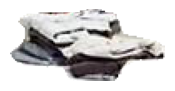

Mask labeling completed in 0.98 seconds
Mask labeling completed in 1.20 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 1.12 seconds
Mask labeling completed in 0.51 seconds
Mask labeling completed in 0.61 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.96 seconds
['laundry', 'laundry', 'laundry', 'laundry', 'laundry', 'laundry', 'laundry', 'laundry', 'laundry', 'laundry']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: triangle, score: 0.9419


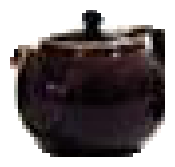

Mask labeling completed in 0.83 seconds
Mask labeling completed in 1.12 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.54 seconds
Mask labeling completed in 1.24 seconds
Mask labeling completed in 0.94 seconds
Mask labeling completed in 0.97 seconds
['teapot', 'teapot', 'teapot', 'teapot', 'teapot', 'teapot', 'teapot', 'teapot', 'teapot', 'teapot']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8029


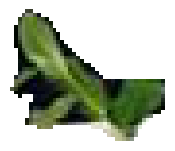

Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.50 seconds
Mask labeling completed in 1.45 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.93 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.67 seconds
['plant', 'plant', 'plant', 'plant', 'plant', 'plant', 'plant', 'plant', 'plant', 'plant']

Processing participant ID = 44

Participant data before center bias removal:  3
Participant data after center bias removal:  0
cuda

Processing participant ID = 45

Participant data before center bias removal:  7
Participant data after center bias removal:  4
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9617


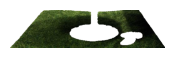

Mask labeling completed in 0.58 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 1.01 seconds
Mask labeling completed in 0.98 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 1.39 seconds
Mask labeling completed in 1.13 seconds
Mask labeling completed in 1.15 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8388


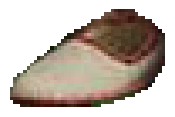

Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.57 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.97 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 1.23 seconds
Mask labeling completed in 1.03 seconds
Mask labeling completed in 1.04 seconds
['slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper', 'slipper']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.7977


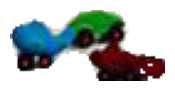

Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 1.24 seconds
Mask labeling completed in 0.61 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.86 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8288


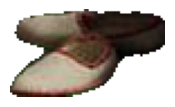

Mask labeling completed in 0.55 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 1.30 seconds
Mask labeling completed in 1.06 seconds
Mask labeling completed in 0.59 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.55 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.81 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 46

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 47

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 48

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 49

Participant data before center bias removal:  0

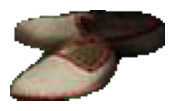

Mask labeling completed in 0.65 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 1.22 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.72 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 64

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 66

Participant data before center bias removal:  5
Participant data after center bias removal:  2
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9699


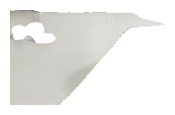

Mask labeling completed in 1.10 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.94 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.66 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8774


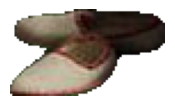

Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 1.10 seconds
Mask labeling completed in 0.95 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.68 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']

Processing participant ID = 67

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 69

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 70

Participant data before center bias removal:  3
Participant data after center bias removal:  0
cuda

Processing participant ID = 71

Participant data before center bias removal:  3

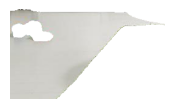

Mask labeling completed in 0.62 seconds
Mask labeling completed in 1.03 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 1.00 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.97 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']

Processing participant ID = 77

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 78

Participant data before center bias removal:  14
Participant data after center bias removal:  11
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9733


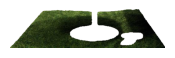

Mask labeling completed in 0.89 seconds
Mask labeling completed in 1.01 seconds
Mask labeling completed in 0.63 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 1.13 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.89 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8516


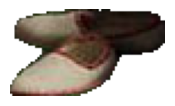

Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 3.54 seconds
Mask labeling completed in 0.91 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8896


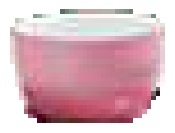

Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.90 seconds
Mask labeling completed in 0.95 seconds
['cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.6454


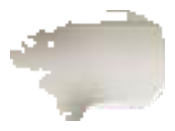

Mask labeling completed in 1.06 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 1.06 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.69 seconds
['cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9450


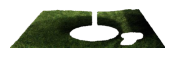

Mask labeling completed in 1.43 seconds
Mask labeling completed in 1.01 seconds
Mask labeling completed in 1.82 seconds
Mask labeling completed in 0.95 seconds
Mask labeling completed in 1.42 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 1.11 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.79 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9640


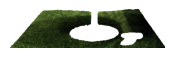

Mask labeling completed in 0.79 seconds
Mask labeling completed in 1.01 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.96 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: triangle, score: 0.8350


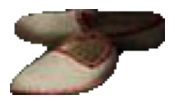

Mask labeling completed in 1.36 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 1.11 seconds
Mask labeling completed in 1.28 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 1.34 seconds
['slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers', 'slippers']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8981


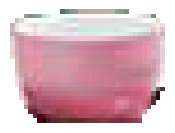

Mask labeling completed in 0.77 seconds
Mask labeling completed in 1.18 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.62 seconds
Mask labeling completed in 0.68 seconds
Mask labeling completed in 0.52 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.59 seconds
Mask labeling completed in 0.70 seconds
['cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9165


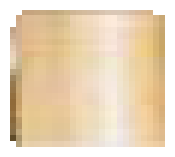

Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 0.93 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.91 seconds
['cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets', 'cabinets']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8198


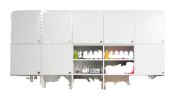

Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 1.70 seconds
Mask labeling completed in 1.05 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.84 seconds
['shelves', 'shelves', 'shelves', 'shelves', 'shelves', 'shelves', 'shelves', 'shelves', 'shelves', 'shelves']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9207


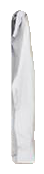

Mask labeling completed in 0.83 seconds
Mask labeling completed in 1.25 seconds
Mask labeling completed in 1.00 seconds
Mask labeling completed in 1.00 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 1.14 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.97 seconds
Mask labeling completed in 0.86 seconds
['ironing', 'ironingboard', 'ironing', 'ironingboard', 'ironing', 'ironing', 'ironingboard', 'ironing', 'ironing', 'ironing']

Processing participant ID = 82

Participant data before center bias removal:  4
Participant data after center bias removal:  1
cuda
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9712


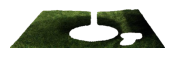

Mask labeling completed in 0.64 seconds
Mask labeling completed in 1.42 seconds
Mask labeling completed in 0.96 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 1.17 seconds
Mask labeling completed in 1.66 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.79 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']

Processing participant ID = 83

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 84

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 86

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 87

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cu

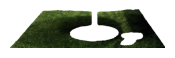

Mask labeling completed in 0.83 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 1.07 seconds
Mask labeling completed in 0.63 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 1.44 seconds
Mask labeling completed in 0.91 seconds
Mask labeling completed in 1.39 seconds
Mask labeling completed in 0.80 seconds
['rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug', 'rug']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: triangle, score: 0.8068


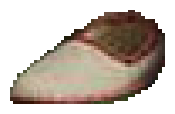

Mask labeling completed in 0.54 seconds
Mask labeling completed in 0.70 seconds
Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.89 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.74 seconds
Mask labeling completed in 0.97 seconds
Mask labeling completed in 0.75 seconds
['toy', 'slipper', 'shoe', 'shoe', 'slipper', 'shoe', 'slipper', 'slipper', 'shoe', 'shoe']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.3833


Mask labeling completed in 5.50 seconds
Mask labeling completed in 1.35 seconds
Mask labeling completed in 0.48 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 1.71 seconds
Mask labeling completed in 0.58 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 0.81 seconds
['desk', 'desk', 'desk', 'desk', 'desk', 'desk', 'desk', 'desk', 'desk', 'desk']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.8444


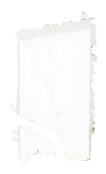

Mask labeling completed in 1.13 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 0.82 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.71 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 1.07 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 1.19 seconds
['plant', 'plant', 'lamp', 'plant', 'window', 'plant', 'plant', 'plant', 'plant', 'plant']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9686


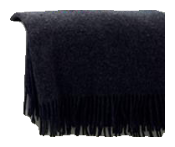

Mask labeling completed in 0.94 seconds
Mask labeling completed in 0.67 seconds
Mask labeling completed in 0.49 seconds
Mask labeling completed in 2.07 seconds
Mask labeling completed in 0.66 seconds
Mask labeling completed in 1.10 seconds
Mask labeling completed in 0.87 seconds
Mask labeling completed in 0.65 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 0.86 seconds
['throw', 'throw', 'throw', 'throw', 'throw', 'throw', 'throw', 'throw', 'throw', 'throw']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9045


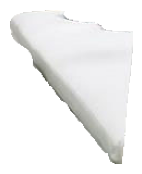

Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.97 seconds
Mask labeling completed in 0.94 seconds
Mask labeling completed in 1.11 seconds
Mask labeling completed in 0.73 seconds
Mask labeling completed in 0.80 seconds
Mask labeling completed in 1.78 seconds
Mask labeling completed in 0.88 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 1.59 seconds
['sofa', 'sofa', 'sofa', 'sofa', 'sofa', 'sofa', 'sofa', 'sofa', 'sofa', 'sofa']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: cross, score: 0.5477


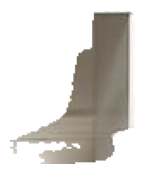

Mask labeling completed in 0.79 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.76 seconds
Mask labeling completed in 1.41 seconds
Mask labeling completed in 0.84 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.74 seconds
['chair', 'chair', 'chair', 'chair', 'chair', 'chair', 'chair', 'chair', 'chair', 'chair']
Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.9004


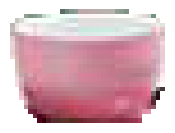

Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.99 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.75 seconds
Mask labeling completed in 0.48 seconds
Mask labeling completed in 0.98 seconds
Mask labeling completed in 0.57 seconds
Mask labeling completed in 0.77 seconds
Mask labeling completed in 0.73 seconds
['cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup', 'cup']

Processing participant ID = 89

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 90

Participant data before center bias removal:  2
Participant data after center bias removal:  0
cuda

Processing participant ID = 93

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 94

Participant data before center bias removal:  3
Participant data after center bias removal:  0
cu

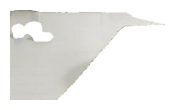

Mask labeling completed in 0.59 seconds
Mask labeling completed in 0.69 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 0.85 seconds
Mask labeling completed in 1.16 seconds
Mask labeling completed in 0.81 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 0.78 seconds
Mask labeling completed in 0.77 seconds
['toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys', 'toys']

Processing participant ID = 101

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 102

Participant data before center bias removal:  1
Participant data after center bias removal:  0
cuda

Processing participant ID = 103

Participant data before center bias removal:  0
Participant data after center bias removal:  0
cuda

Processing participant ID = 104

Participant data before center bias removal:  0
Participant data after center bias 

In [17]:
# load the experiment data
datapath =  os.path.join("data", "experiments", "XSQ_Expt1_Data_2.csv")
data = pd.read_csv(datapath)

IMG_ID = 1


print("Image Path:", imgpath)


CONDITION_ID = 1
GROUP_ID = 1
EXP_TYPE = "exp"


for img_id in [1]: # substitute this with the range of all images

    print(f"Processing image ID: {IMG_ID}")
    print(f"\tGenerating general scene description...")

    # create an image object
    # todo: get target automatic from Monica's data
    imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}{EXP_TYPE}.jpg")
    imageData = ImageData(imgpath, target=[430, 510, 545, 595],  img_type = "exp")

    # genetate a scene description
    llm = create_llm_instance("openai", "gpt-4o", temperature = 0.1)  # the lower the temperature, the more deterministic is the output
    scene_description =  llm.describe_scene(imageData)

    participants = data[data.ItemNum == IMG_ID].ParticipantID.unique()
    print(participants)


    for part_ID in participants: # just running for 1 participant. Remove this to run for all

        participant =  Participant(part_ID)
        print(f"\nProcessing participant ID = {part_ID}\n")

        task = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=3)

        task_data = task.data.copy()

        # image segmentation object
        mask_gen = SAM2(sam_model_path = SAM_MODEL, sam_model_config = SAM_CONFIG, task = task)

        for fix_indx in task_data.index:

            # select fixation
            fix_prompt = task_data.iloc[fix_indx]

            # segment the image in the region that the participant is fixating
            mask = mask_gen.compute_masks_with_prompt(fix_indx, fix_prompt, output_path=os.path.join(RESULTS_DIR, "Masks"), DEBUG=True, save_mask=True)
            mask.plot()

            # generate label candidates for the mask
            mask_labels = []
            for i in range(0, 10):  # asking the LLM to label the image 10x so we can get a distribution of labels
                mask_label = llm.label_mask(mask, imageData, use_context = True, context = scene_description) 
                mask_labels.append(mask_label)
            mask.labels = mask_labels
            print(mask_labels)

            # save the mask object
            mask_gen.save_mask_object(mask, mask.path.replace(".png", ""))



## Generate Scene Descriptions

In [1]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
import os

In [2]:

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

In [3]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
scene_description =  llm.describe_scene(image_data=image_data)
scene_description

Scene description completed in 9.21 seconds


'1. **Scene Overview**:  \n   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.\n\n2. **Identified Objects**:  \n   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.\n   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.\n   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.\n   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.\n   - **Chair**: A black chair is placed in front of the desk.\n   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative obje

In [5]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm = create_llm_instance("ollama", "llava:34b", temperature=0.1)
scene_description =  llm.describe_scene(image_data=image_data)
scene_description

Ollama connection successful. Using model: llava:34b
Scene description completed in 638.79 seconds


"1. **Scene Overview**: The image depicts a modern, multi-purpose room that combines elements of both a living area and a laundry/workspace. The space is well-lit and features clean lines, with various furniture pieces and appliances arranged to create a functional environment for work, leisure, and household chores.\n2. **Identified Objects**: \n   - A white cabinet against the wall on the left side of the room.\n   - On top of this cabinet, there are several items including what appears to be a stack of books or folders, a decorative object resembling an abstract sculpture, and possibly some small appliances or office supplies.\n   - Adjacent to the cabinet, there is a white countertop with various objects on it, including what could be cleaning supplies, stationery, or craft materials. A black lamp with a curved neck stands out among these items.\n   - Below the countertop, a washing machine is installed into the cabinetry, indicating that this room also serves as a laundry area.\n 

## KG Generator

In [1]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

In [ ]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm_provider = "openai"

# load img scene description
scene_descr_path = os.path.join(RESULTS_DIR, "SceneDescriptions", f"{llm_provider}_results", f"IMG_{IMG_ID}_{IMG_TYPE}_descr.txt")
image_data.load_scene_description(scene_descr_path)

1. **Scene Overview**:  
   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.

2. **Identified Objects**:  
   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.
   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.
   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.
   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.
   - **Chair**: A black chair is placed in front of the desk.
   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative objects.
   - 

In [4]:
# get all masks related to the image
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")

# list files in directory
masks = []
mask_files = os.listdir(masks_path_dir)
mask_files = [file for file in mask_files if file.endswith('.pkl')]
mask_files = [file for file in mask_files if f"IMG_{IMG_ID}_type_{IMG_TYPE}" in file] # select all the masks of a specific image
for file in mask_files:
    with open(os.path.join(masks_path_dir, file), 'rb') as mask_file:
        mask_data = pickle.load(mask_file)
        mask_data.get_most_frequent_label()
        masks.append(mask_data)

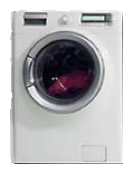

['washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing']
washing
1.0


In [5]:
# checking if everything is okay
masks[5].plot()
print(masks[5].labels)
print(masks[5].most_freq_label)
print(masks[5].most_freq_prob)

In [6]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

In [ ]:
# triples = KG.generate_triples( masks )
# triples

In [ ]:
# kg_triples = KG.parse_triples( triples )

In [7]:


KG.load_triples( os.path.join(RESULTS_DIR, "KnowledgeGraph", "triples_final", "IMG_1_exp_triples.txt") );


Successfully loaded 51 triples from .\outputs\KnowledgeGraph\triples_final\IMG_1_exp_triples.txt


Relationship matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_knowledge_matrix.png


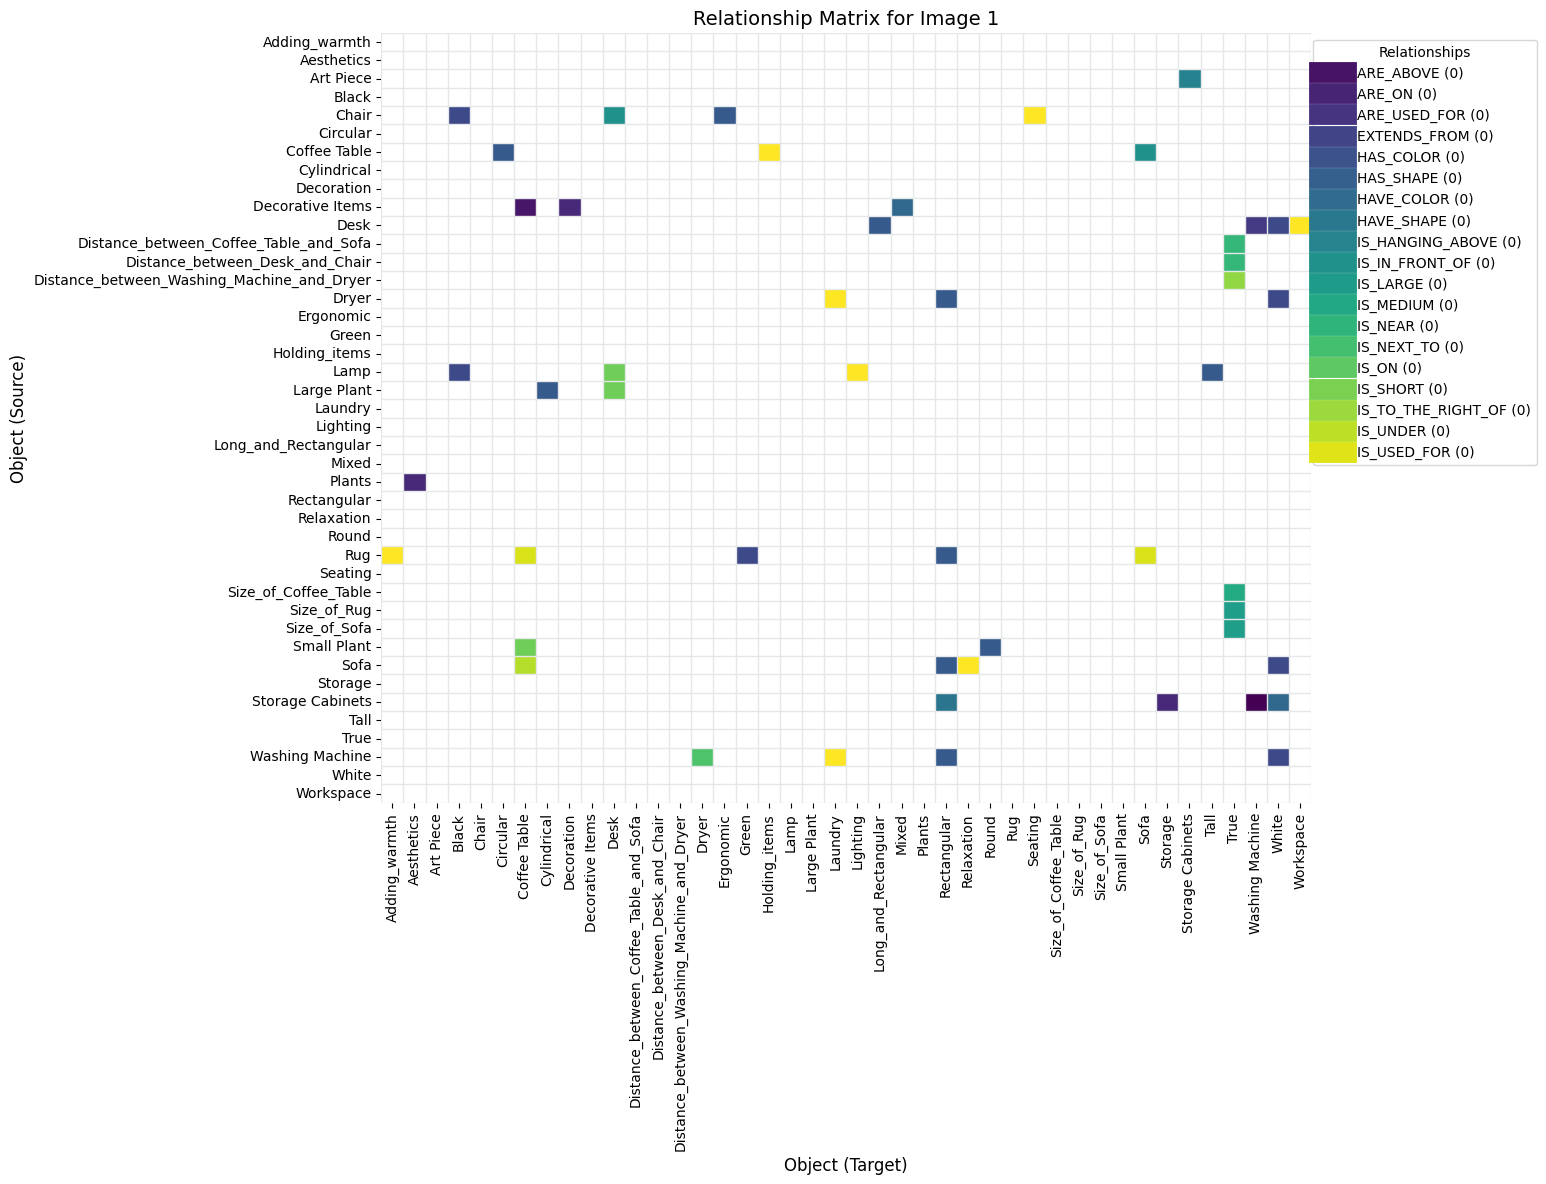

In [8]:
KG.plot_relationship_matrix()

In [9]:
KG.build_graph()

In [10]:
kg_matrix = KG.get_adjacency_matrix( save=True)
kg_matrix

Adjacency matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_adjacency_matrix.csv


,Washing Machine,Dryer,Storage Cabinets,Desk,Chair,Coffee Table,Sofa,Rug,Lamp,Small Plant,...,Round,Cylindrical,Tall,Distance_between_Washing_Machine_and_Dryer,True,Distance_between_Desk_and_Chair,Distance_between_Coffee_Table_and_Sofa,Size_of_Coffee_Table,Size_of_Sofa,Size_of_Rug
Washing Machine,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dryer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Storage Cabinets,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Desk,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Chair,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Coffee Table,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sofa,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rug,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Lamp,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Small Plant,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


Professional knowledge graph saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.png
PDF version saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.pdf


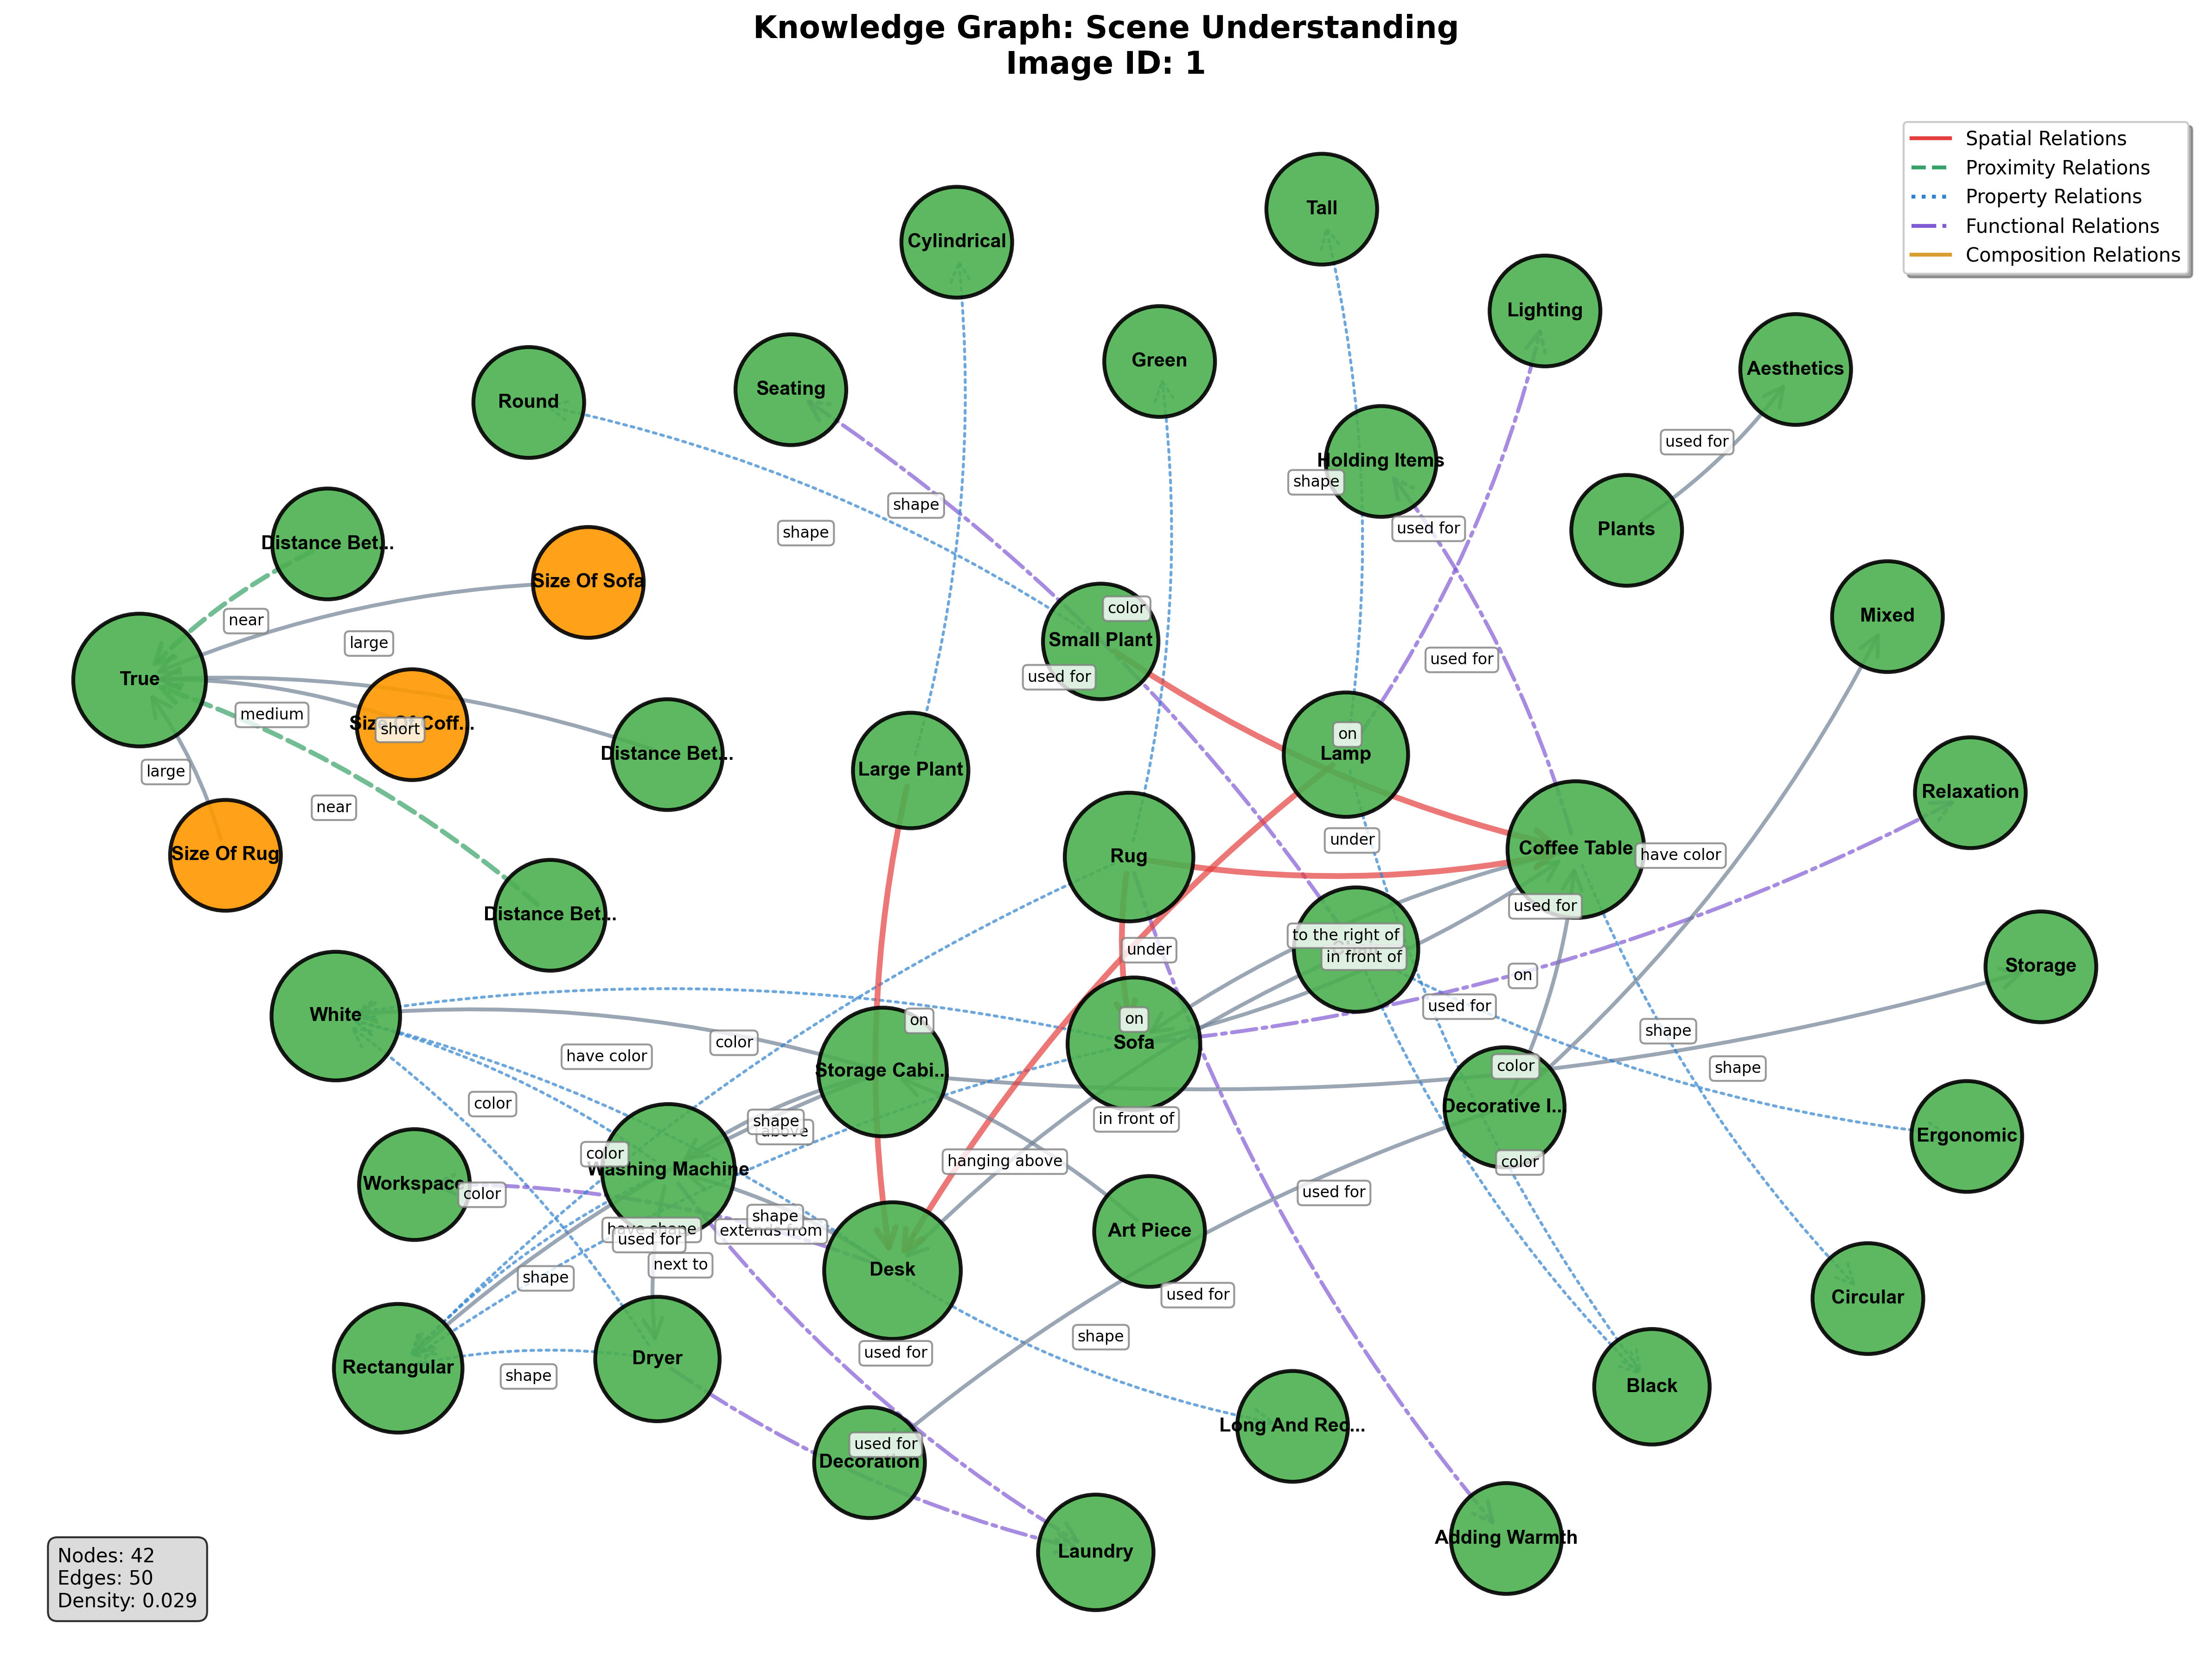

In [12]:

KG.plot_knowledge_graph(layout_algorithm="spring", scale=1.0, k_param = 10.0)